In [1]:
#Librery
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt

In [2]:
#up files from Drive
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')
#Read
path = 'drive/MyDrive/Colab Notebooks/Fisica_Computacional_1/figures/'
filename3 = 'Laplace_df_3.png'
filename2 = 'Laplace_df_2.png'
filename4 = 'Laplace_df_4.png'
filename5 = 'Laplace_df_capacitor.png'

Mounted at /content/drive


### Potential and Electric field from a capacitor

####Lab1_4_PDE_capacitor:

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:

\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}
\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}

However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

* Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

* Compute numerically (use finite difference method) the electric field.

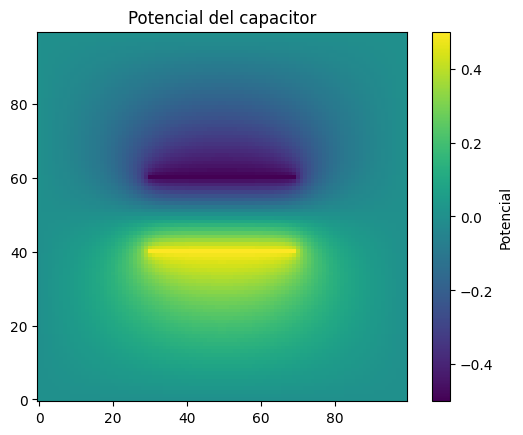

In [4]:
# parámetros
Nx, Ny = 100, 100
phi = np.zeros((Nx, Ny))

# voltaje (para no complicarnos mucho)
V0 = 1.0

# definir placas (posición en la malla)
plate_y1 = 40
plate_y2 = 60
plate_x_start = 30
plate_x_end = 70

# condiciones de frontera en las placas
phi[plate_x_start:plate_x_end, plate_y1] = V0/2
phi[plate_x_start:plate_x_end, plate_y2] = -V0/2

#aplicando el metodo que enseño el profe
for iteration in range(5000):
    phi_old = phi.copy()

    for i in range(1, Nx-1):
        for j in range(1, Ny-1):
            # no actualizar puntos de las placas
            if (plate_x_start <= i < plate_x_end and (j == plate_y1 or j == plate_y2)):
                continue

            phi[i,j] = 0.25 * (phi_old[i+1,j] + phi_old[i-1,j] +  #ahora si, actualizando con la info de los vecinos
                               phi_old[i,j+1] + phi_old[i,j-1])

# Gráfica del potencial
plt.imshow(phi.T, origin='lower') #usando lo que dijo el profe (muy linda grafica)
plt.colorbar(label='Potencial')
plt.title("Potencial del capacitor")
plt.show()

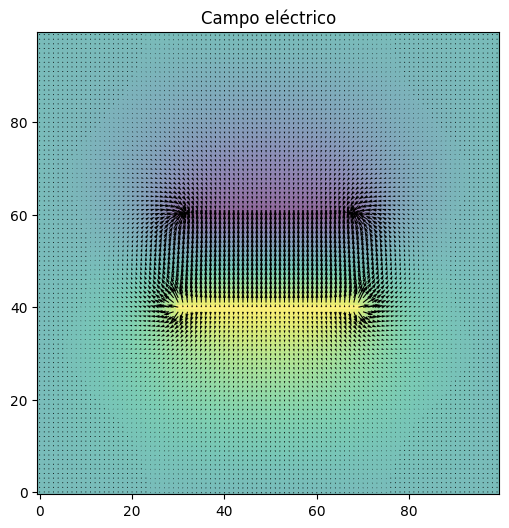

In [5]:
#aplicandole el metodo al campo electrico
Ex, Ey = np.gradient(-phi)

plt.figure(figsize=(6,6))
plt.imshow(phi.T, origin='lower', alpha=0.6) #muy bacana esta funcion profe
plt.quiver(Ex.T, Ey.T)
plt.title("Campo eléctrico")
plt.show()